# SPECK 32/64 Cipher 


##  Overview
- **Cipher**: SPECK 32/64 (32-bit block, 64-bit key, up to 22 rounds)
- **Models used**: Logistic Regression, MLP , CNN
- **Analysis done through**: Bitwise accuracy, Hamming distance, Avalanche effect, Generalization


## 1. Setup & Imports

In [1]:
from __future__ import annotations

import os
import pickle
import hashlib
import time
import random as rnd
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.cuda.amp as amp
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

# Create output directories
for d in ["data/cache_speck", "data/cache_speck_gen",
          "results_speck/models"]:
    os.makedirs(d, exist_ok=True)

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = (DEVICE.type == "cuda")

print(f"Device  : {DEVICE}")


Device  : cuda


## 2. SPECK 32/64 Cipher Implementation

SPECK 32/64 is an ARX (Add-Rotate-XOR) cipher:
- **Block size**: 32 bits (two 16-bit words x, y)
- **Key size**: 64 bits (four 16-bit words)
- **Full rounds**: 22
- **Round function**: `x = ROR(x,7) + y ⊕ k`,  `y = ROL(y,2) ⊕ x`

In [2]:
WORD_SIZE   = 16
BLOCK_BITS  = 32
KEY_BITS    = 64
FULL_ROUNDS = 22
MOD         = 1 << WORD_SIZE
MASK        = MOD - 1

ALPHA = 7   # right-rotation amount for x word
BETA  = 2   # left-rotation amount for y word

In [3]:

# Rotation helpers

def _ror(val: int, r: int) -> int:
    # Rotate 16-bit word right by r bits.
    return ((val >> r) | (val << (WORD_SIZE - r))) & MASK

def _rol(val: int, r: int) -> int:
    # Rotate 16-bit word left by r bits.
    return ((val << r) | (val >> (WORD_SIZE - r))) & MASK

# key scheduling
def _expand_key(key: int, num_rounds: int) -> list:
    """Expand 64-bit key into `num_rounds` 16-bit round keys."""
    k = [(key >> (WORD_SIZE * i)) & MASK for i in range(4)]
    round_keys = [k[0]]
    l = [k[1], k[2], k[3]]

    for i in range(num_rounds - 1):
        new_l = ((_ror(l[i % 3], ALPHA) + round_keys[i]) & MASK) ^ i
        new_k = _rol(round_keys[i], BETA) ^ new_l
        l.append(new_l)
        round_keys.append(new_k)

    return round_keys[:num_rounds]

In [4]:

def _round_enc(x: int, y: int, k: int):
    x = (_ror(x, ALPHA) + y) & MASK
    x ^= k
    y  = _rol(y, BETA) ^ x
    return x, y

def _round_dec(x: int, y: int, k: int):
    y  = (x ^ y)
    y  = _ror(y, BETA)
    x  = ((x ^ k) - y) & MASK
    x  = _rol(x, ALPHA)
    return x, y


def speck_encrypt(plaintext: int, key: int, num_rounds: int = FULL_ROUNDS) -> int:
    assert 0 <= plaintext < (1 << BLOCK_BITS)
    assert 0 <= key        < (1 << KEY_BITS)
    assert 1 <= num_rounds <= FULL_ROUNDS

    round_keys = _expand_key(key, num_rounds)
    x = (plaintext >> WORD_SIZE) & MASK
    y =  plaintext               & MASK
    for k in round_keys:
        x, y = _round_enc(x, y, k)
    return ((x << WORD_SIZE) | y) & 0xFFFFFFFF


def speck_decrypt(ciphertext: int, key: int, num_rounds: int = FULL_ROUNDS) -> int:
    assert 0 <= ciphertext < (1 << BLOCK_BITS)
    assert 0 <= key         < (1 << KEY_BITS)
    assert 1 <= num_rounds  <= FULL_ROUNDS

    round_keys = _expand_key(key, num_rounds)
    x = (ciphertext >> WORD_SIZE) & MASK
    y =  ciphertext               & MASK
    for k in reversed(round_keys):
        x, y = _round_dec(x, y, k)
    return ((x << WORD_SIZE) | y) & 0xFFFFFFFF


class SpeckCipher:
    BLOCK_BITS = 32
    KEY_BITS   = 64

    def __init__(self, key: int, num_rounds: int = FULL_ROUNDS):
        assert 0 <= key < (1 << self.KEY_BITS)
        assert 1 <= num_rounds <= FULL_ROUNDS
        self.key         = key
        self.num_rounds  = num_rounds
        self._round_keys = _expand_key(key, num_rounds)

    def encrypt(self, plaintext: int) -> int:
        return speck_encrypt(plaintext, self.key, self.num_rounds)

    def decrypt(self, ciphertext: int) -> int:
        return speck_decrypt(ciphertext, self.key, self.num_rounds)

## 3. Dataset Generation

For each `num_rounds` value we generate `(plaintext_bits, ciphertext_bits)` pairs:
- **Input X**: 32-bit plaintext → bit vector (LSB first)
- **Output y**: 32-bit ciphertext → bit vector (LSB first)

In [5]:

def batch_int_to_bits(values: np.ndarray, num_bits: int) -> np.ndarray:

    shifts = np.arange(0, num_bits)
    return ((values[:, None] >> shifts) & 1).astype(np.float32)

def bitwise_accuracy(y_true, y_pred):
    return float(np.mean((y_pred >= 0.5).astype(np.float32) == y_true))

def hamming_distance(y_true, y_pred):
    pred = (y_pred >= 0.5).astype(np.float32)
    return float(np.mean(np.sum(np.abs(pred - y_true), axis=1)))

def exact_match_accuracy(y_true, y_pred):
    pred = (y_pred >= 0.5).astype(np.float32)
    return float(np.mean(np.all(pred == y_true, axis=1)))

In [6]:
def generate_dataset(
    num_rounds: int,
    num_samples: int,
    key: int,
    seed: int = 42,
    cache_dir: str = "data/cache_speck",
):
    os.makedirs(cache_dir, exist_ok=True)
    tag = hashlib.md5(
        f"speck_{num_rounds}_{num_samples}_{key}_{seed}".encode()
    ).hexdigest()[:10]
    cache_path = os.path.join(cache_dir, f"speck_r{num_rounds}_{tag}.pkl")

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            X, y = pickle.load(f)
        print(f"  [Cache] r={num_rounds}: loaded from {cache_path}")
        return X, y

    rng    = np.random.default_rng(seed)
    cipher = SpeckCipher(key, num_rounds)

    plaintexts  = rng.integers(0, 1 << BLOCK_BITS, size=num_samples, dtype=np.int64)
    ciphertexts = np.array(
        [cipher.encrypt(int(p)) for p in plaintexts], dtype=np.int64
    )

    X = batch_int_to_bits(plaintexts,  BLOCK_BITS)
    y = batch_int_to_bits(ciphertexts, BLOCK_BITS)

    with open(cache_path, "wb") as f:
        pickle.dump((X, y), f)
    print(f"  [Generated] r={num_rounds}: {num_samples} samples {cache_path}")
    return X, y


def build_all_datasets(
    round_list, num_samples, key,
    val_split=0.15, test_split=0.15,
    seed=42, cache_dir="data/cache_speck",
):
    datasets = {}
    rng     = np.random.default_rng(seed)
    n_test  = int(num_samples * test_split)
    n_val   = int(num_samples * val_split)
    n_train = num_samples - n_val - n_test

    for r in round_list:
        X, y = generate_dataset(r, num_samples, key, seed=seed, cache_dir=cache_dir)
        idx  = rng.permutation(num_samples)
        datasets[r] = {
            "X_train": X[idx[:n_train]],
            "y_train": y[idx[:n_train]],
            "X_val":   X[idx[n_train:n_train + n_val]],
            "y_val":   y[idx[n_train:n_train + n_val]],
            "X_test":  X[idx[n_train + n_val:]],
            "y_test":  y[idx[n_train + n_val:]],
        }
    return datasets

In [7]:
KEY         = 0x0F0E0D0C0B0A0908
ROUND_LIST  = [1, 2, 3, 4, 5, 6, 8, 12, 16, 22]
NUM_SAMPLES = 30_000
EPOCHS      = 50
BATCH_SIZE  = 512
LR_RATE     = 2e-3
PATIENCE    = 6
SEED        = 42

RESULTS_DIR      = "results_speck"
MODELS_DIR       = "results_speck/models"
DATA_DIR         = "data/cache_speck"
RANDOM_BITACC    = 0.50
RANDOM_HAMMING   = 16.0
LEARN_THRESHOLD  = 0.55

COLORS = {"lr": "#e74c3c", "mlp": "#2980b9", "cnn": "#27ae60"}
LABELS = {"lr": "Logistic Regression", "mlp": "MLP", "cnn": "CNN"}

print(f"Configuration:")
print(f"  Key     : 0x{KEY:016X}")
print(f"  Rounds  : {ROUND_LIST}")
print(f"  Samples : {NUM_SAMPLES:,}")
print(f"  Epochs  : {EPOCHS}  |  Batch: {BATCH_SIZE} ")


Configuration:
  Key     : 0x0F0E0D0C0B0A0908
  Rounds  : [1, 2, 3, 4, 5, 6, 8, 12, 16, 22]
  Samples : 30,000
  Epochs  : 50  |  Batch: 512 


In [8]:
print("Building datasets ...")
t0 = time.time()

datasets = build_all_datasets(
    round_list  = ROUND_LIST,
    num_samples = NUM_SAMPLES,
    key         = KEY,
    cache_dir   = DATA_DIR,
    seed        = SEED,
)

r0 = ROUND_LIST[0]
print(f"\nSample shapes for r={r0}:")
for split in ["X_train", "y_train", "X_val", "X_test"]:
    print(f"  {split:8s}: {datasets[r0][split].shape}")

Building datasets ...
  [Cache] r=1: loaded from data/cache_speck\speck_r1_dfbfb9bb60.pkl
  [Cache] r=2: loaded from data/cache_speck\speck_r2_c7bc6a9c5a.pkl
  [Cache] r=3: loaded from data/cache_speck\speck_r3_cb5a0f44d2.pkl
  [Cache] r=4: loaded from data/cache_speck\speck_r4_d26e3b7fd7.pkl
  [Cache] r=5: loaded from data/cache_speck\speck_r5_4f85941052.pkl
  [Cache] r=6: loaded from data/cache_speck\speck_r6_a8870193a0.pkl
  [Cache] r=8: loaded from data/cache_speck\speck_r8_8a37b23dca.pkl
  [Cache] r=12: loaded from data/cache_speck\speck_r12_291137ef6f.pkl
  [Cache] r=16: loaded from data/cache_speck\speck_r16_e1ad8633d2.pkl
  [Cache] r=22: loaded from data/cache_speck\speck_r22_ee388311bf.pkl

Sample shapes for r=1:
  X_train : (21000, 32)
  y_train : (21000, 32)
  X_val   : (4500, 32)
  X_test  : (4500, 32)


## 4. Model Definitions

Three models are implemented and compared:
1. **Logistic Regression** — linear baseline per output bit
2. **MLP** — deep residual network (32 → 256 → 512 → 512+skip → 256 → 32)
3. **CNN** — dilated 1-D CNN (kernel-7 captures ROR-7 rotation in SPECK)

In [9]:
class LogisticRegressionModel:
    def __init__(self, max_iter=2000, C=1.0):
        self.model  = MultiOutputClassifier(
            LogisticRegression(max_iter=max_iter, C=C, solver="lbfgs"), n_jobs=-1
        )
        self.scaler = StandardScaler()

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self.model.fit(self.scaler.fit_transform(X_train), y_train.astype(int))
        return {}

    def predict_proba(self, X):
        return np.stack(
            [p[:, 1] for p in self.model.predict_proba(self.scaler.transform(X))],
            axis=1
        )

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(np.float32)

    def evaluate(self, X, y):
        pred = self.predict(X)
        return {
            "bitwise_accuracy": float(np.mean(pred == y)),
            "mean_hamming":     float(np.mean(np.sum(np.abs(pred - y), axis=1))),
            "exact_match":      float(np.mean(np.all(pred == y, axis=1))),
        }

    def save(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump({"model": self.model, "scaler": self.scaler}, path)

    def load(self, path):
        obj = joblib.load(path)
        self.model, self.scaler = obj["model"], obj["scaler"]

In [10]:
IN_DIM  = 32
OUT_DIM = 32

class MLPNet(nn.Module):

    def __init__(self, dropout=0.25):
        super().__init__()
        self.b1   = nn.Sequential(nn.Linear(32,  256), nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(dropout))
        self.b2   = nn.Sequential(nn.Linear(256, 512), nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(dropout))
        self.b3   = nn.Sequential(nn.Linear(512, 512), nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(dropout))
        self.b4   = nn.Sequential(nn.Linear(512, 256), nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(32, 512)    # residual projection
        self.head = nn.Linear(256, 32)

    def forward(self, x):
        h = self.b1(x)
        h = self.b2(h)
        h = self.b3(h) + self.proj(x)    
        h = self.b4(h)
        return self.head(h)



class CNNNet(nn.Module):

    def __init__(self, dropout=0.25):
        super().__init__()

        def block(ic, oc, k, d):
            return nn.Sequential(
                nn.Conv1d(ic, oc, k, padding=(k // 2) * d, dilation=d),
                nn.BatchNorm1d(oc), nn.GELU(), nn.Dropout(dropout)
            )

        self.convs = nn.Sequential(
            block(1,   64,  7, 1),   
            block(64,  128, 5, 2),   
            block(128, 128, 3, 4),   
            block(128, 64,  3, 1),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 32)
        )

    def forward(self, x):
        x = x.unsqueeze(1)          
        x = self.convs(x)           
        x = self.gap(x).squeeze(2)  
        return self.head(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 5. Training Pipeline

In [11]:

def make_loader(X, y, shuffle=True):
    ds = torch.utils.data.TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return torch.utils.data.DataLoader(
        ds,
        batch_size          = BATCH_SIZE,
        shuffle             = shuffle,
        num_workers         = 0,
        pin_memory          = False,
        persistent_workers  = False,
    )


def train_neural(net, data, label=""):

    net     = net.to(DEVICE)
    opt     = torch.optim.AdamW(net.parameters(), lr=LR_RATE, weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    loss_fn = nn.BCEWithLogitsLoss()
    scaler  = amp.GradScaler(enabled=USE_AMP)

    train_loader = make_loader(data["X_train"], data["y_train"])
    val_X = torch.tensor(data["X_val"], dtype=torch.float32).to(DEVICE)
    val_y = torch.tensor(data["y_val"], dtype=torch.float32).to(DEVICE)

    best_val, best_state, no_improve = 0.0, None, 0
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        net.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with amp.autocast(enabled=USE_AMP):
                loss = loss_fn(net(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            total_loss += loss.item() * len(xb)
        sched.step()

        net.eval()
        with torch.no_grad(), amp.autocast(enabled=USE_AMP):
            logits  = net(val_X)
        pred    = (torch.sigmoid(logits) >= 0.5).float()
        val_acc = (pred == val_y).float().mean().item()

        if epoch % 10 == 0:
            print(f"    Epoch {epoch:3d}/{EPOCHS} | "
                  f"loss={total_loss/len(data['X_train']):.4f} | "
                  f"val_bitacc={val_acc:.4f}")

        if val_acc > best_val + 1e-4:
            best_val   = val_acc
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"    Early stop at epoch {epoch} (best val={best_val:.4f})")
                break

    if best_state:
        net.load_state_dict(best_state)

    # Final test metrics
    net.eval()
    Xt = torch.tensor(data["X_test"], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        pred = (torch.sigmoid(net(Xt)) >= 0.5).cpu().numpy().astype(np.float32)
    y = data["y_test"]
    metrics = {
        "bitwise_accuracy": float(np.mean(pred == y)),
        "mean_hamming":     float(np.mean(np.sum(np.abs(pred - y), axis=1))),
        "exact_match":      float(np.mean(np.all(pred == y, axis=1))),
        "train_time_s":     time.time() - t0,
    }
    return net, metrics


def train_lr(data):
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(data["X_train"])
    model  = MultiOutputClassifier(
        LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs"), n_jobs=-1
    )
    model.fit(Xs, data["y_train"].astype(int))

    Xt     = scaler.transform(data["X_test"])
    probas = np.stack([p[:, 1] for p in model.predict_proba(Xt)], axis=1)
    pred   = (probas >= 0.5).astype(np.float32)
    y      = data["y_test"]
    return {
        "bitwise_accuracy": float(np.mean(pred == y)),
        "mean_hamming":     float(np.mean(np.sum(np.abs(pred - y), axis=1))),
        "exact_match":      float(np.mean(np.all(pred == y, axis=1))),
    }

In [12]:
all_results = {"lr": {}, "mlp": {}, "cnn": {}}

print("── Logistic Regression ──────────────────────────────────────")
for r in ROUND_LIST:
    t0      = time.time()
    metrics = train_lr(datasets[r])
    elapsed = time.time() - t0
    all_results["lr"][r] = metrics
    
    print(f"  r={r:2d} | bitacc={metrics['bitwise_accuracy']:.4f} | "
          f"hamming={metrics['mean_hamming']:.2f} | {elapsed:.1f}s")

── Logistic Regression ──────────────────────────────────────
  r= 1 | bitacc=0.5000 | hamming=16.00 | 17.7s
  r= 2 | bitacc=0.5015 | hamming=15.95 | 0.4s
  r= 3 | bitacc=0.4993 | hamming=16.02 | 0.4s
  r= 4 | bitacc=0.4990 | hamming=16.03 | 0.4s
  r= 5 | bitacc=0.5022 | hamming=15.93 | 0.4s
  r= 6 | bitacc=0.4995 | hamming=16.02 | 0.4s
  r= 8 | bitacc=0.5009 | hamming=15.97 | 0.4s
  r=12 | bitacc=0.5002 | hamming=15.99 | 0.4s
  r=16 | bitacc=0.4997 | hamming=16.01 | 0.4s
  r=22 | bitacc=0.4990 | hamming=16.03 | 0.4s


In [13]:

print("── MLP ──────────────────────────────────────────────────────")
for r in ROUND_LIST:
    print(f"\n  rounds = {r}")
    net, metrics = train_neural(MLPNet(), datasets[r], label=f"MLP r={r}")
    all_results["mlp"][r] = metrics

    ckpt = os.path.join(MODELS_DIR, f"mlp_r{r}.pt")
    torch.save(net.state_dict(), ckpt)

    print(f"   bitacc={metrics['bitwise_accuracy']:.4f} | "
          f"hamming={metrics['mean_hamming']:.2f} | "
          f"time={metrics['train_time_s']:.1f}s")

── MLP ──────────────────────────────────────────────────────

  rounds = 1
    Epoch  10/50 | loss=0.5708 | val_bitacc=0.5982
    Epoch  20/50 | loss=0.5688 | val_bitacc=0.6047
    Epoch  30/50 | loss=0.5592 | val_bitacc=0.6210
    Epoch  40/50 | loss=0.5541 | val_bitacc=0.6301
    Epoch  50/50 | loss=0.5529 | val_bitacc=0.6310
   bitacc=0.6315 | hamming=11.79 | time=40.8s

  rounds = 2
    Epoch  10/50 | loss=0.6905 | val_bitacc=0.4985
    Early stop at epoch 10 (best val=0.5007)
   bitacc=0.4999 | hamming=16.00 | time=7.8s

  rounds = 3
    Early stop at epoch 8 (best val=0.5028)
   bitacc=0.4994 | hamming=16.02 | time=5.9s

  rounds = 4
    Epoch  10/50 | loss=0.6903 | val_bitacc=0.5006
    Early stop at epoch 10 (best val=0.5045)
   bitacc=0.5012 | hamming=15.96 | time=8.2s

  rounds = 5
    Early stop at epoch 7 (best val=0.5007)
   bitacc=0.5006 | hamming=15.98 | time=6.3s

  rounds = 6
    Early stop at epoch 8 (best val=0.5021)
   bitacc=0.4999 | hamming=16.00 | time=6.9s

  r

In [14]:

print("── CNN ──────────────────────────────────────────────────────")
for r in ROUND_LIST:
    print(f"\n  rounds = {r}")
    net, metrics = train_neural(CNNNet(), datasets[r], label=f"CNN r={r}")
    all_results["cnn"][r] = metrics

    ckpt = os.path.join(MODELS_DIR, f"cnn_r{r}.pt")
    torch.save(net.state_dict(), ckpt)

    print(f"   bitacc={metrics['bitwise_accuracy']:.4f} | "
          f"hamming={metrics['mean_hamming']:.2f} | "
          f"time={metrics['train_time_s']:.1f}s")

# Save all results
with open(os.path.join(RESULTS_DIR, "results.pkl"), "wb") as f:
    pickle.dump(all_results, f)


── CNN ──────────────────────────────────────────────────────

  rounds = 1
    Epoch  10/50 | loss=0.6823 | val_bitacc=0.5437
    Epoch  20/50 | loss=0.6745 | val_bitacc=0.5559
    Epoch  30/50 | loss=0.6640 | val_bitacc=0.5688
    Epoch  40/50 | loss=0.6587 | val_bitacc=0.5707
    Epoch  50/50 | loss=0.6576 | val_bitacc=0.5720
   bitacc=0.5741 | hamming=13.63 | time=80.0s

  rounds = 2
    Early stop at epoch 7 (best val=0.5022)
   bitacc=0.5020 | hamming=15.94 | time=11.7s

  rounds = 3
    Early stop at epoch 7 (best val=0.5004)
   bitacc=0.4998 | hamming=16.01 | time=11.9s

  rounds = 4
    Epoch  10/50 | loss=0.6930 | val_bitacc=0.5001
    Early stop at epoch 13 (best val=0.5006)
   bitacc=0.4982 | hamming=16.06 | time=16.7s

  rounds = 5
    Early stop at epoch 7 (best val=0.5002)
   bitacc=0.5003 | hamming=15.99 | time=11.6s

  rounds = 6
    Early stop at epoch 8 (best val=0.5040)
   bitacc=0.5004 | hamming=15.99 | time=18.0s

  rounds = 8
    Early stop at epoch 7 (best val=0

## 6. Avalanche Effect Analysis

Measures how many output bits flip when a single plaintext bit is flipped. Ideal cipher: 16/32 bits flip on average (50%).

Computing avalanche effect (2,000 pairs per round count) ...
  r= 1 | avg diff bits = 4.00/32  (ideal=16)
  r= 2 | avg diff bits = 10.37/32  (ideal=16)
  r= 3 | avg diff bits = 12.59/32  (ideal=16)
  r= 4 | avg diff bits = 16.12/32  (ideal=16)
  r= 5 | avg diff bits = 15.86/32  (ideal=16)
  r= 6 | avg diff bits = 16.04/32  (ideal=16)
  r= 8 | avg diff bits = 16.06/32  (ideal=16)
  r=12 | avg diff bits = 16.04/32  (ideal=16)
  r=16 | avg diff bits = 15.95/32  (ideal=16)
  r=22 | avg diff bits = 15.98/32  (ideal=16)


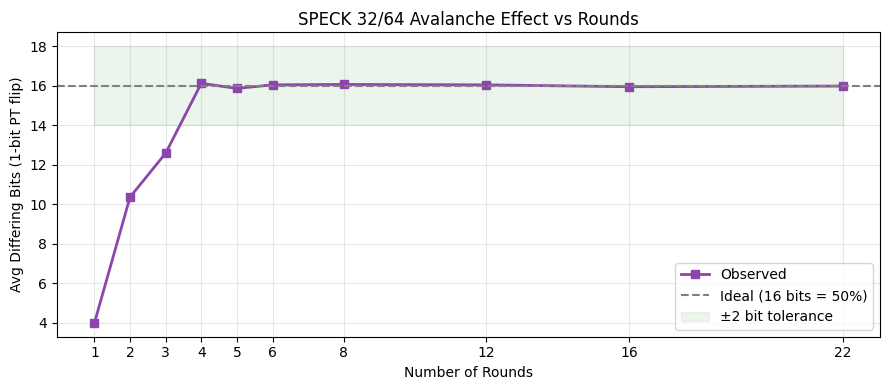

[Plot] Saved → results_speck/avalanche.png


In [15]:
print("Computing avalanche effect (2,000 pairs per round count) ...")
rnd.seed(0)
avg_diffs = []

for r in ROUND_LIST:
    diffs = []
    for _ in range(2000):
        pt1 = rnd.randint(0, (1 << 32) - 1)
        pt2 = pt1 ^ (1 << rnd.randint(0, 31))
        c   = SpeckCipher(KEY, r)
        diffs.append(bin(c.encrypt(pt1) ^ c.encrypt(pt2)).count("1"))
    avg = sum(diffs) / len(diffs)
    avg_diffs.append(avg)
    print(f"  r={r:2d} | avg diff bits = {avg:.2f}/32  (ideal=16)")


# Avalance Plot

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ROUND_LIST, avg_diffs, marker="s", color="#8e44ad", linewidth=2, label="Observed")
ax.axhline(16, color="gray", linestyle="--", linewidth=1.5, label="Ideal (16 bits = 50%)")
ax.fill_between(ROUND_LIST, 14, 18, alpha=0.08, color="green", label="±2 bit tolerance")
ax.set_xlabel("Number of Rounds")
ax.set_ylabel("Avg Differing Bits (1-bit PT flip)")
ax.set_title("SPECK 32/64 Avalanche Effect vs Rounds")
ax.set_xticks(ROUND_LIST)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "avalanche.png"), dpi=150)
plt.show()
print(f"[Plot] Saved → results_speck/avalanche.png")

## 7. Results & Plots

In [16]:

print("=" * 72)
print("  SPECK 32/64  BITWISE ACCURACY SUMMARY")
print(f"  {'Rounds':>8}  {'LR Acc':>10}  {'MLP Acc':>10}  {'CNN Acc':>10}  {'Best':>12}")
print("-" * 72)
for r in ROUND_LIST:
    lr_a  = all_results["lr" ][r]["bitwise_accuracy"]
    mlp_a = all_results["mlp"][r]["bitwise_accuracy"]
    cnn_a = all_results["cnn"][r]["bitwise_accuracy"]
    best  = max(lr_a, mlp_a, cnn_a)
    bname = ["LR","MLP","CNN"][[lr_a,mlp_a,cnn_a].index(best)]

    print(f"  {r:>8}  {lr_a:>10.4f}  {mlp_a:>10.4f}  {cnn_a:>10.4f}  {bname} {best:.4f}")
print("=" * 72)
print(f"  Random = {RANDOM_BITACC}  |  Signal threshold = {LEARN_THRESHOLD}")

# Learnability analysis
print(f"\n[Analysis] Max learnable rounds (bitacc > {LEARN_THRESHOLD}):")
for m_name, res in all_results.items():
    learnable = [r for r in ROUND_LIST if res[r]["bitwise_accuracy"] > LEARN_THRESHOLD]
    mx = max(learnable) if learnable else 0
    print(f"  {LABELS[m_name]:25s}: max r = {mx}")

  SPECK 32/64  BITWISE ACCURACY SUMMARY
    Rounds      LR Acc     MLP Acc     CNN Acc          Best
------------------------------------------------------------------------
         1      0.5000      0.6315      0.5741  MLP 0.6315
         2      0.5015      0.4999      0.5020  CNN 0.5020
         3      0.4993      0.4994      0.4998  CNN 0.4998
         4      0.4990      0.5012      0.4982  MLP 0.5012
         5      0.5022      0.5006      0.5003  LR 0.5022
         6      0.4995      0.4999      0.5004  CNN 0.5004
         8      0.5009      0.4994      0.4986  LR 0.5009
        12      0.5002      0.4978      0.5019  CNN 0.5019
        16      0.4997      0.5021      0.4971  MLP 0.5021
        22      0.4990      0.4983      0.5003  CNN 0.5003
  Random = 0.5  |  Signal threshold = 0.55

[Analysis] Max learnable rounds (bitacc > 0.55):
  Logistic Regression      : max r = 0
  MLP                      : max r = 1
  CNN                      : max r = 1


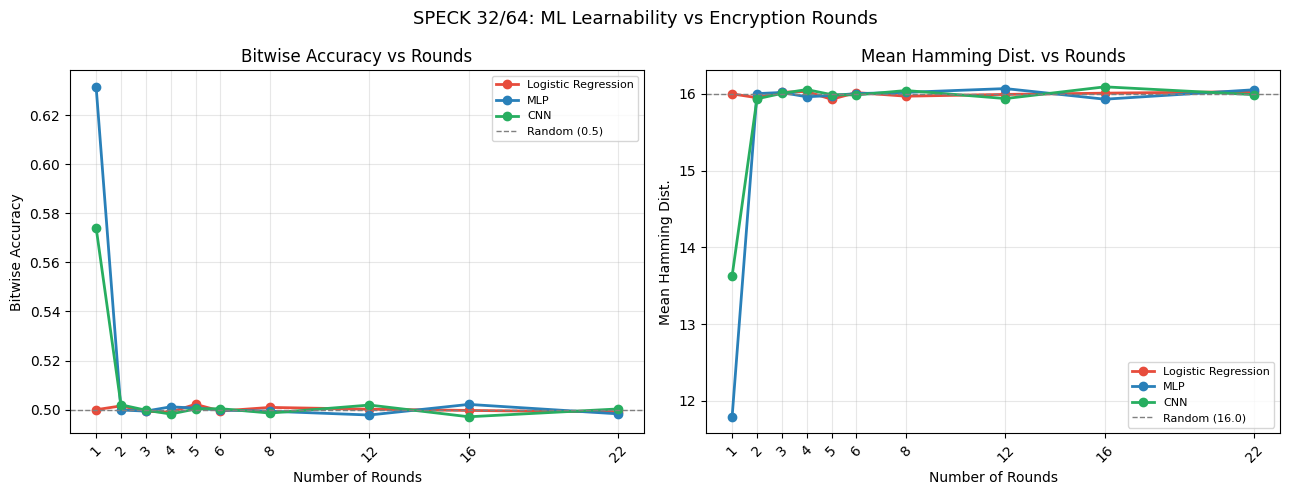

[Plot] Saved → results_speck/combined_metrics.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metric_cfg = [
    ("bitwise_accuracy", "Bitwise Accuracy",   RANDOM_BITACC),
    ("mean_hamming",     "Mean Hamming Dist.",  RANDOM_HAMMING),
]

for ax, (metric, ylabel, hline) in zip(axes, metric_cfg):
    for m_name, res in all_results.items():
        vals = [res[r][metric] for r in ROUND_LIST]
        ax.plot(ROUND_LIST, vals, marker="o", linewidth=2,
                color=COLORS[m_name], label=LABELS[m_name])
    if hline is not None:
        ax.axhline(hline, color="gray", linestyle="--", linewidth=1,
                   label=f"Random ({hline})")
    ax.set_xlabel("Number of Rounds")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + " vs Rounds")
    ax.set_xticks(ROUND_LIST)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("SPECK 32/64: ML Learnability vs Encryption Rounds", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "combined_metrics.png"), dpi=150)
plt.show()
print(f"[Plot] Saved : results_speck/combined_metrics.png")

## 8. Generalization Evaluation (Unseen Plaintexts)

**Phase I requirement**: Check whether models generalize to plaintexts never seen during training.  
A fresh RNG seed (`999` vs training `42`) guarantees completely new plaintexts.

In [18]:
NEW_SEED    = 999
NEW_SAMPLES = 5_000

def load_mlp_ckpt(r):
    path = os.path.join(MODELS_DIR, f"mlp_r{r}.pt")
    if not os.path.exists(path):
        return None
    m = MLPNet().to(DEVICE)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval()
    return m


@torch.no_grad()
def predict_model(model, X):
    Xt   = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    prob = torch.sigmoid(model(Xt)).cpu().numpy()
    return (prob >= 0.5).astype(np.float32), prob


print(f"Generalisation setup:")
print(f"  New seed    : {NEW_SEED}  (training used seed={SEED})")
print(f"  New samples : {NEW_SAMPLES:,} fresh plaintexts")

Generalisation setup:
  New seed    : 999  (training used seed=42)
  New samples : 5,000 fresh plaintexts


In [ ]:

gen_results = {}

print("=" * 60)
print("  SPECK 32/64 Generalisation (Unseen Plaintexts)")
print("=" * 60)

for r in ROUND_LIST:
    print(f"\n  r = {r}")

    X_new, y_new = generate_dataset(
        num_rounds  = r,
        num_samples = NEW_SAMPLES,
        key         = KEY,
        seed        = NEW_SEED,
        cache_dir   = "data/cache_speck_gen",
    )

    model = load_mlp_ckpt(r)
    if model is None:
        print(f"    No checkpoint found for r={r}")
        continue

    y_pred, prob = predict_model(model, X_new)
    bitacc  = float(np.mean(y_pred == y_new))
    hamming = float(np.mean(np.sum(np.abs(y_pred - y_new), axis=1)))
    exact   = float(np.mean(np.all(y_pred == y_new, axis=1)))

    gen_results[r] = {
        "bitwise_accuracy": bitacc,
        "mean_hamming":     hamming,
        "exact_match":      exact,
    }

    delta = bitacc - 0.50

    print(f"    Bitwise accuracy : {bitacc:.4f}  ({delta:+.4f} vs random)")
    print(f"    Mean Hamming     : {hamming:.2f} / 32 bits")
    print(f"    Exact match      : {exact:.6f}")

  SPECK 32/64 Generalisation (Unseen Plaintexts)

  r = 1
  [Cache] r=1: loaded from data/cache_speck_gen\speck_r1_9691934ecb.pkl
    Bitwise accuracy : 0.6300  (+0.1300 vs random)  SIGNAL!
    Mean Hamming     : 11.84 / 32 bits
    Exact match      : 0.000000

  r = 2
  [Cache] r=2: loaded from data/cache_speck_gen\speck_r2_9ac385ef66.pkl
    Bitwise accuracy : 0.4991  (-0.0009 vs random)
    Mean Hamming     : 16.03 / 32 bits
    Exact match      : 0.000000

  r = 3
  [Cache] r=3: loaded from data/cache_speck_gen\speck_r3_821d5af2f8.pkl
    Bitwise accuracy : 0.5009  (+0.0009 vs random)
    Mean Hamming     : 15.97 / 32 bits
    Exact match      : 0.000000

  r = 4
  [Cache] r=4: loaded from data/cache_speck_gen\speck_r4_51d199eddb.pkl
    Bitwise accuracy : 0.5007  (+0.0007 vs random)
    Mean Hamming     : 15.98 / 32 bits
    Exact match      : 0.000000

  r = 5
  [Cache] r=5: loaded from data/cache_speck_gen\speck_r5_74317298a7.pkl
    Bitwise accuracy : 0.5002  (+0.0002 vs random

In [20]:
print("\n" + "=" * 60)
print("  GENERALISATION SUMMARY  (MLP on unseen plaintexts)")
print("=" * 60)
print(f"  {'Rounds':>8}  {'BitAcc':>8}  {'Hamming':>9}  {'vs Random':>10}")
print(f"  {'─'*46}")
for r, m in gen_results.items():
    delta = m['bitwise_accuracy'] - 0.50
    
    print(f"  {r:>8}  {m['bitwise_accuracy']:>8.4f}  "
          f"{m['mean_hamming']:>9.2f}  {delta:>+10.4f}")
print("=" * 60)

if gen_results:
    print("\n  TRAIN (test split) vs GENERALISATION — MLP")
    print(f"  {'─'*52}")
    print(f"  {'Rounds':>8}  {'Train BitAcc':>13}  {'Gen BitAcc':>11}  {'Gap':>6}")
    print(f"  {'─'*52}")
    for r in ROUND_LIST:
        if r not in gen_results or r not in all_results["mlp"]:
            continue
        tr  = all_results["mlp"][r]["bitwise_accuracy"]
        ge  = gen_results[r]["bitwise_accuracy"]
        gap = tr - ge
        print(f"  {r:>8}  {tr:>13.4f}  {ge:>11.4f}  {gap:>+6.4f}")
    print("\n  Gap ~ 0 : learnt cipher structure, not memorisation.")


  GENERALISATION SUMMARY  (MLP on unseen plaintexts)
    Rounds    BitAcc    Hamming   vs Random
  ──────────────────────────────────────────────
         1    0.6300      11.84     +0.1300
         2    0.4991      16.03     -0.0009
         3    0.5009      15.97     +0.0009
         4    0.5007      15.98     +0.0007
         5    0.5002      15.99     +0.0002
         6    0.4997      16.01     -0.0003
         8    0.4998      16.01     -0.0002
        12    0.5007      15.98     +0.0007
        16    0.4999      16.00     -0.0001
        22    0.5017      15.95     +0.0017

  TRAIN (test split) vs GENERALISATION — MLP
  ────────────────────────────────────────────────────
    Rounds   Train BitAcc   Gen BitAcc     Gap
  ────────────────────────────────────────────────────
         1         0.6315       0.6300  +0.0016
         2         0.4999       0.4991  +0.0008
         3         0.4994       0.5009  -0.0014
         4         0.5012       0.5007  +0.0004
         5        

## 9. Final Summary

In [21]:

print("\n" + "=" * 78)
print("  FINAL RESULTS — SPECK 32/64")
print("=" * 78)
print(f"  {'Rounds':>8} │ {'LR Acc':>8} │ {'MLP Acc':>8} │ {'CNN Acc':>8} │"
      f" {'LR Ham':>7} │ {'MLP Ham':>7} │ {'CNN Ham':>7}")
for r in ROUND_LIST:
    la = all_results["lr" ][r]["bitwise_accuracy"]
    ma = all_results["mlp"][r]["bitwise_accuracy"]
    ca = all_results["cnn"][r]["bitwise_accuracy"]
    lh = all_results["lr" ][r]["mean_hamming"]
    mh = all_results["mlp"][r]["mean_hamming"]
    ch = all_results["cnn"][r]["mean_hamming"]
    print(f"  {r:>8} │ {la:>8.4f} │ {ma:>8.4f} │ {ca:>8.4f} │"
          f" {lh:>7.2f} │ {mh:>7.2f} │ {ch:>7.2f}")



  FINAL RESULTS — SPECK 32/64
    Rounds │   LR Acc │  MLP Acc │  CNN Acc │  LR Ham │ MLP Ham │ CNN Ham
         1 │   0.5000 │   0.6315 │   0.5741 │   16.00 │   11.79 │   13.63
         2 │   0.5015 │   0.4999 │   0.5020 │   15.95 │   16.00 │   15.94
         3 │   0.4993 │   0.4994 │   0.4998 │   16.02 │   16.02 │   16.01
         4 │   0.4990 │   0.5012 │   0.4982 │   16.03 │   15.96 │   16.06
         5 │   0.5022 │   0.5006 │   0.5003 │   15.93 │   15.98 │   15.99
         6 │   0.4995 │   0.4999 │   0.5004 │   16.02 │   16.00 │   15.99
         8 │   0.5009 │   0.4994 │   0.4986 │   15.97 │   16.02 │   16.04
        12 │   0.5002 │   0.4978 │   0.5019 │   15.99 │   16.07 │   15.94
        16 │   0.4997 │   0.5021 │   0.4971 │   16.01 │   15.93 │   16.09
        22 │   0.4990 │   0.4983 │   0.5003 │   16.03 │   16.05 │   15.99
